In [3]:
import pickle
from pathlib import Path
import pandas as pd
from markov_models import MarkovModel
import logging
from collections import Counter

languages = ['ENG', 'FRA', 'DEU']
processing_types = ['phones', 'sylls', 'words']
text_types = ['words', 'sentences']
n_values = [1, 2, 3, 4]

results = []

for language in languages:
    for processing_type in processing_types:
        print(f"Proccesing type: {processing_type}")
        if processing_type == 'words': 
            data_path = Path(f"produced_data/{language}/ipa_corpus_{language}.pkl")
        if processing_type == 'phones':
            data_path = Path(f"produced_data/{language}/phones/phonized_{language}.pkl")
        if processing_type == 'sylls':
            data_path = Path(f"produced_data/{language}/sylls/syllabified_{language}.pkl")

        if not data_path.exists():
            logging.warning(f"Data for {language} not found at {data_path}. Skipping...")
            continue

        with open(data_path, "rb") as f:
            data = pickle.load(f)

        if processing_type == 'phones' or processing_type == 'sylls':
            # Flatten the IPA data based on processing type
            units = [unit for sentence in data for word in sentence for unit in word]
        else:
            units = [word for sentence in data for word in sentence]

        unit_counts = Counter(units)
        unique_units = len(unit_counts)

        print("First sentence:", data[0])
        print(f"Sample units (top 10): {unit_counts.most_common(10)}")
        print(f"Total tokens: {len(units)}")
        print(f"Unique units count: {unique_units}")
        

        for text_type in text_types:
            for n in n_values:
                model_path = Path(f"produced_data/{language}/{processing_type}/{language}_{text_type}_markov_model_{n}gram.pkl")
                if not model_path.exists():
                    logging.warning(f"Model for {language}, {processing_type}, {text_type}, n={n} not found at {model_path}. Skipping...")
                    continue

                model = MarkovModel.load(model_path)

                total_ngrams = sum(model.ngram_counts.values())
                unique_prefixes = len(model.prefix_counts)

            
                results.append({
                    "language": language,
                    "processing_type": processing_type,
                    "text_type": text_type,
                    "n": n,
                    "total_ngrams": total_ngrams,
                    "unique_prefixes": unique_prefixes,
                    "unique_units": unique_units
                })

# Convert to DataFrame
df = pd.DataFrame(results)
print(df)


Proccesing type: phones
Proccesing type: sylls
First sentence: [['maɪ'], ['peə', 'ɹənts'], ['wʊd'], ['ɹɪ', 'pjuː', 'dɪ', 'eɪt'], ['maɪ'], ['bɹʌ', 'ðə'], ['ɪf'], ['ðeɪ'], ['ɛ', 'və'], ['faʊnd'], ['aʊt'], ['hiː'], ['wɒz'], ['ɡeɪ']]
Sample units (top 10): [('ðə', 2250), ('aɪ', 1447), ('tuː', 1320), ('eɪ', 1153), ('juː', 1006), ('ɪn', 883), ('ɪz', 806), ('ɒv', 743), ('ɐ', 595), ('fɔː', 531)]
Total tokens: 58400
Unique units count: 3554
Text type: words
Text type: sentences


Proccesing type: phones
Proccesing type: sylls
First sentence: [['ʒə'], ['ne'], ['pa'], ['fɛ'], ['la'], ['di', 'fe', 'ʁɑ̃s'], ['ɑ̃tʁ']]
Sample units (top 10): [('a', 1927), ('də', 1264), ('la', 1070), ('e', 771), ('lə', 764), ('le', 741), ('il', 713), ('pa', 702), ('ʒə', 692), ('de', 690)]
Total tokens: 47051
Unique units count: 2064
Text type: words
Text type: sentences


Proccesing type: phones
Proccesing type: sylls
First sentence: [['vas'], ['pa', 'siːɾt'], ['ɪn'], ['dɛɾ'], ['høː', 'lə']]
Sample units (top 10): [('ɪç', 1279), ('tɔm', 1178), ('ɡə', 988), ('tə', 952), ('ɪst', 778), ('ɛɾ', 773), ('das', 673), ('bə', 648), ('diː', 638), ('nə', 577)]
Total tokens: 51351
Unique units count: 2690
Text type: words
Text type: sentences
   language processing_type  text_type  n  total_ngrams  unique_prefixes  \
0       ENG           sylls      words  1         58400                1   
1       ENG           sylls      words  2         16218             1238   
2       ENG           sylls      words  3          4810             1917   
3       ENG           sylls      words  4          1341              726   
4       ENG           sylls  sentences  1         58400                1   
5       ENG           sylls  sentences  2         53400             3434   
6       ENG           sylls  sentences  3         48411            24581   
7       ENG           sylls

In [4]:
# --- SPLIT INTO SEMANTIC SUBSETS ---

# By n-gram order
df_1gram = df[df["n"] == 1]
df_2gram = df[df["n"] == 2]
df_3gram = df[df["n"] == 3]
df_4gram = df[df["n"] == 4]

# By processing type
df_phones = df[df["processing_type"] == "phones"]
df_sylls = df[df["processing_type"] == "sylls"]

# By text granularity
df_words = df[df["text_type"] == "words"]
df_sentences = df[df["text_type"] == "sentences"]

# By language
for language in languages: 
    df_language =  df[df["language"] == language]


# Change df as needed; change **{'color': 'white'} if not in dark mode
df_2gram.style.set_caption("Summary")\
    .format(precision=0)\
    .bar(subset=["total_ngrams", "unique_prefixes", "unique_units"], color='blue')\
    .set_properties(subset=["total_ngrams", "unique_prefixes", "unique_units"],
                    **{'color': 'white'})

,language,processing_type,text_type,n,total_ngrams,unique_prefixes,unique_units
1,ENG,sylls,words,2,16218,1238,3554
5,ENG,sylls,sentences,2,53400,3434,3554
9,FRA,sylls,words,2,14569,820,2064
13,FRA,sylls,sentences,2,42055,1970,2064
17,DEU,sylls,words,2,19282,1629,2690
21,DEU,sylls,sentences,2,46351,2623,2690


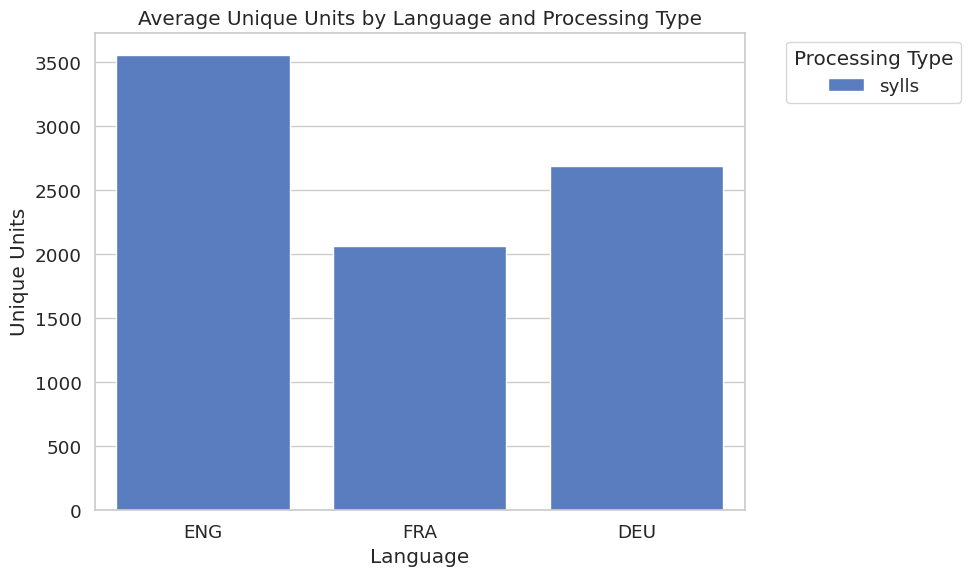

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Plot styling
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("Set2")


# Plot: Unique units by Language and Processing Type

variable = "unique_units" # Change to "total_ngrams" or "unique_prefixes" as needed
var_display = variable.replace("_", " ").title()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x="language",
    y=variable,
    hue="processing_type",  # Differentiates by unit type, e.g., syllables vs phonemes
    estimator=np.mean,
    ci=None,
    palette="muted"
)
plt.title(f"Average {var_display} by Language and Processing Type")
plt.ylabel(var_display)
plt.xlabel("Language")
plt.legend(title="Processing Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

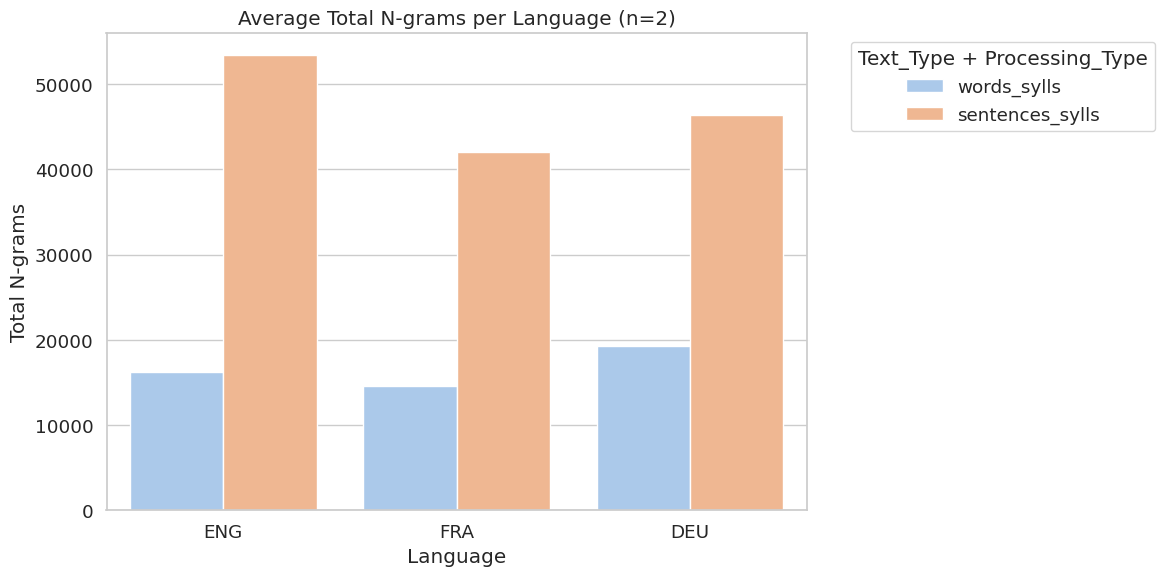

In [12]:
# Total N-grams by Text Type and Processing Type, per Language
# Filter for a specific n-gram order
n_target = 2  # change this to the desired n
df_n = df[df["n"] == n_target].copy()

# Create combo key, change key if needed
combo_keys = ["text_type", "processing_type"]
df_n["type_combo"] = df_n[combo_keys].astype(str).agg("_".join, axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_n,
    x="language",
    y="total_ngrams",
    hue="type_combo",
    estimator=np.mean,
    ci=None,
    palette="pastel"
)
plt.title(f"Average Total N-grams per Language (n={n_target})")
plt.ylabel("Total N-grams")
plt.xlabel("Language")
plt.legend(title=" + ".join(combo_keys).title(), bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()